# What Drives Rental Prices in Airbnb in NYC?

## Objective

This project analyzes Airbnb listings in New York City to identify the key drivers of rental pricing. The goal is to understand how structural features (e.g., location, room type) and behavioral signals (e.g., reviews, availability) influence price. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
import os
import kagglehub
import pandas as pd

# plotting style
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.5,
    "axes.prop_cycle": cycler(color=['#A8CDECFF', '#682C37FF','#F6955EFF', '#9B6981FF', '#7887A4FF', '#A89F8EFF']),
    'figure.figsize' : [8.0, 4.0],
    'figure.dpi' :250,
    'image.aspect': 7 
})

# 1. Load the data 

## Data Overview
The dataset contains information on Airbnb listings in New York City from 2019, including:

- Location (borough and neighborhood)
- Room type (entire home, private room, shared room)
- Number of reviews
- Availability
- Price

In [2]:
# Download dataset
data_dir = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

# Inspect contents
print(os.listdir(data_dir))

# Load CSV
df = pd.read_csv(os.path.join(data_dir, "AB_NYC_2019.csv"))

['New_York_City_.png', 'AB_NYC_2019.csv']


# 2. Data Cleaning

Several preprocessing steps were applied:

- Removed identifier columns (`id`, `name`, `host_id`, `host_name`) as they do not provide predictive value
- Handled missing values in `reviews_per_month` by filling with 0 (indicating no reviews)
- Removed extreme price outliers to improve model stability

In [3]:
#The `host_name` and `name` columns are removed as they are identifiers and do not provide predictive value for pricing.
df = df.drop(columns=["host_name", "name"])

In [4]:
df.shape

(48895, 14)

The dataset contains approximately 48895 listings. Are there any missing values? 

In [5]:
df.isnull().sum()

id                                    0
host_id                               0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Missing values are primarily present in last_review and reviews_per_month. Lets drop those too. 

In [6]:
df = df.drop(columns=["last_review", "reviews_per_month"])

## 2. Distribution of Listings by Borough

In [7]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

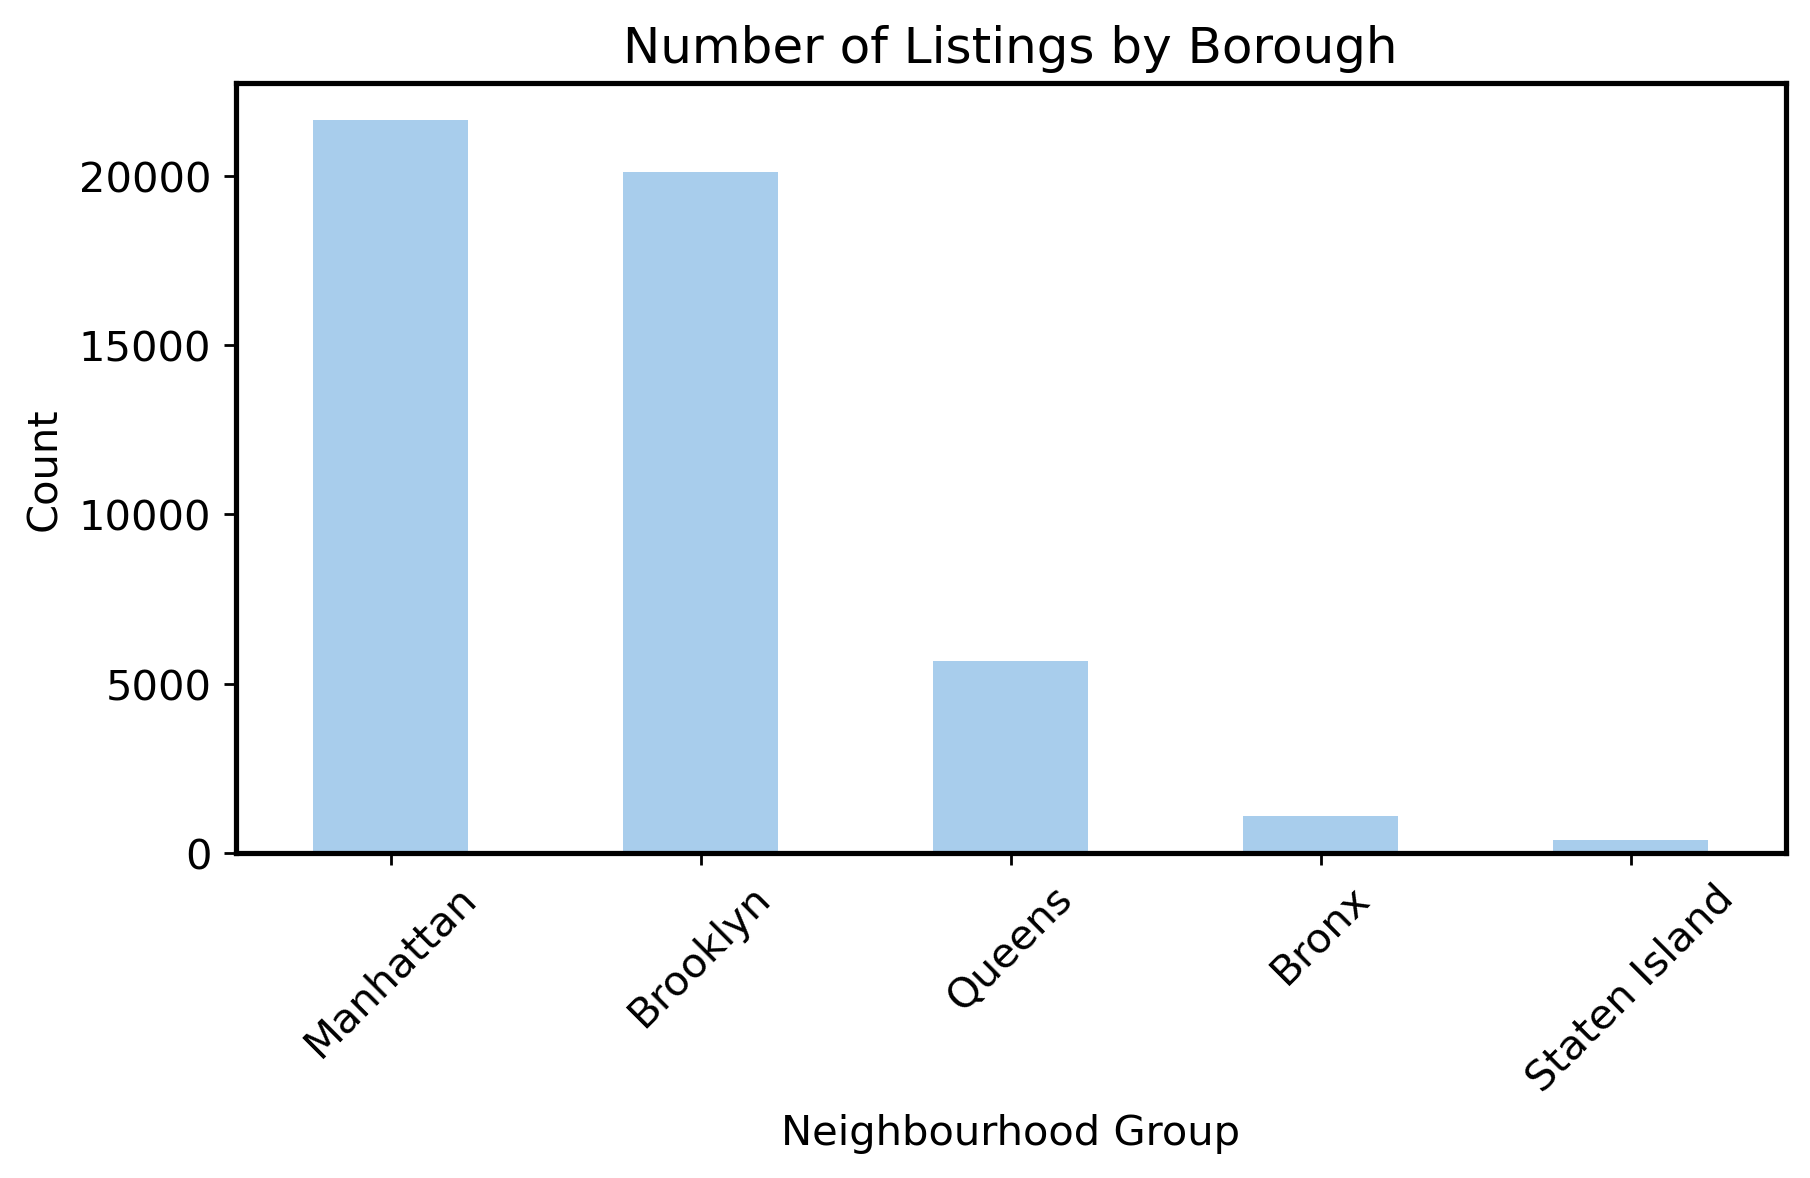

In [8]:
df["neighbourhood_group"].value_counts().plot(kind="bar")

plt.title("Number of Listings by Borough")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [9]:
df["neighbourhood_group"].value_counts(normalize=True) * 100

neighbourhood_group
Manhattan        44.301053
Brooklyn         41.116679
Queens           11.588097
Bronx             2.231312
Staten Island     0.762859
Name: proportion, dtype: float64

We see that Manhatten and Brooklyn contains the majority of the listings (>40%). Staten Island is the least represented (<1%). This imbalance is important to consider when modeling, as it may influence feature importance and model predictions.

## 3. Price Distribution By Borough

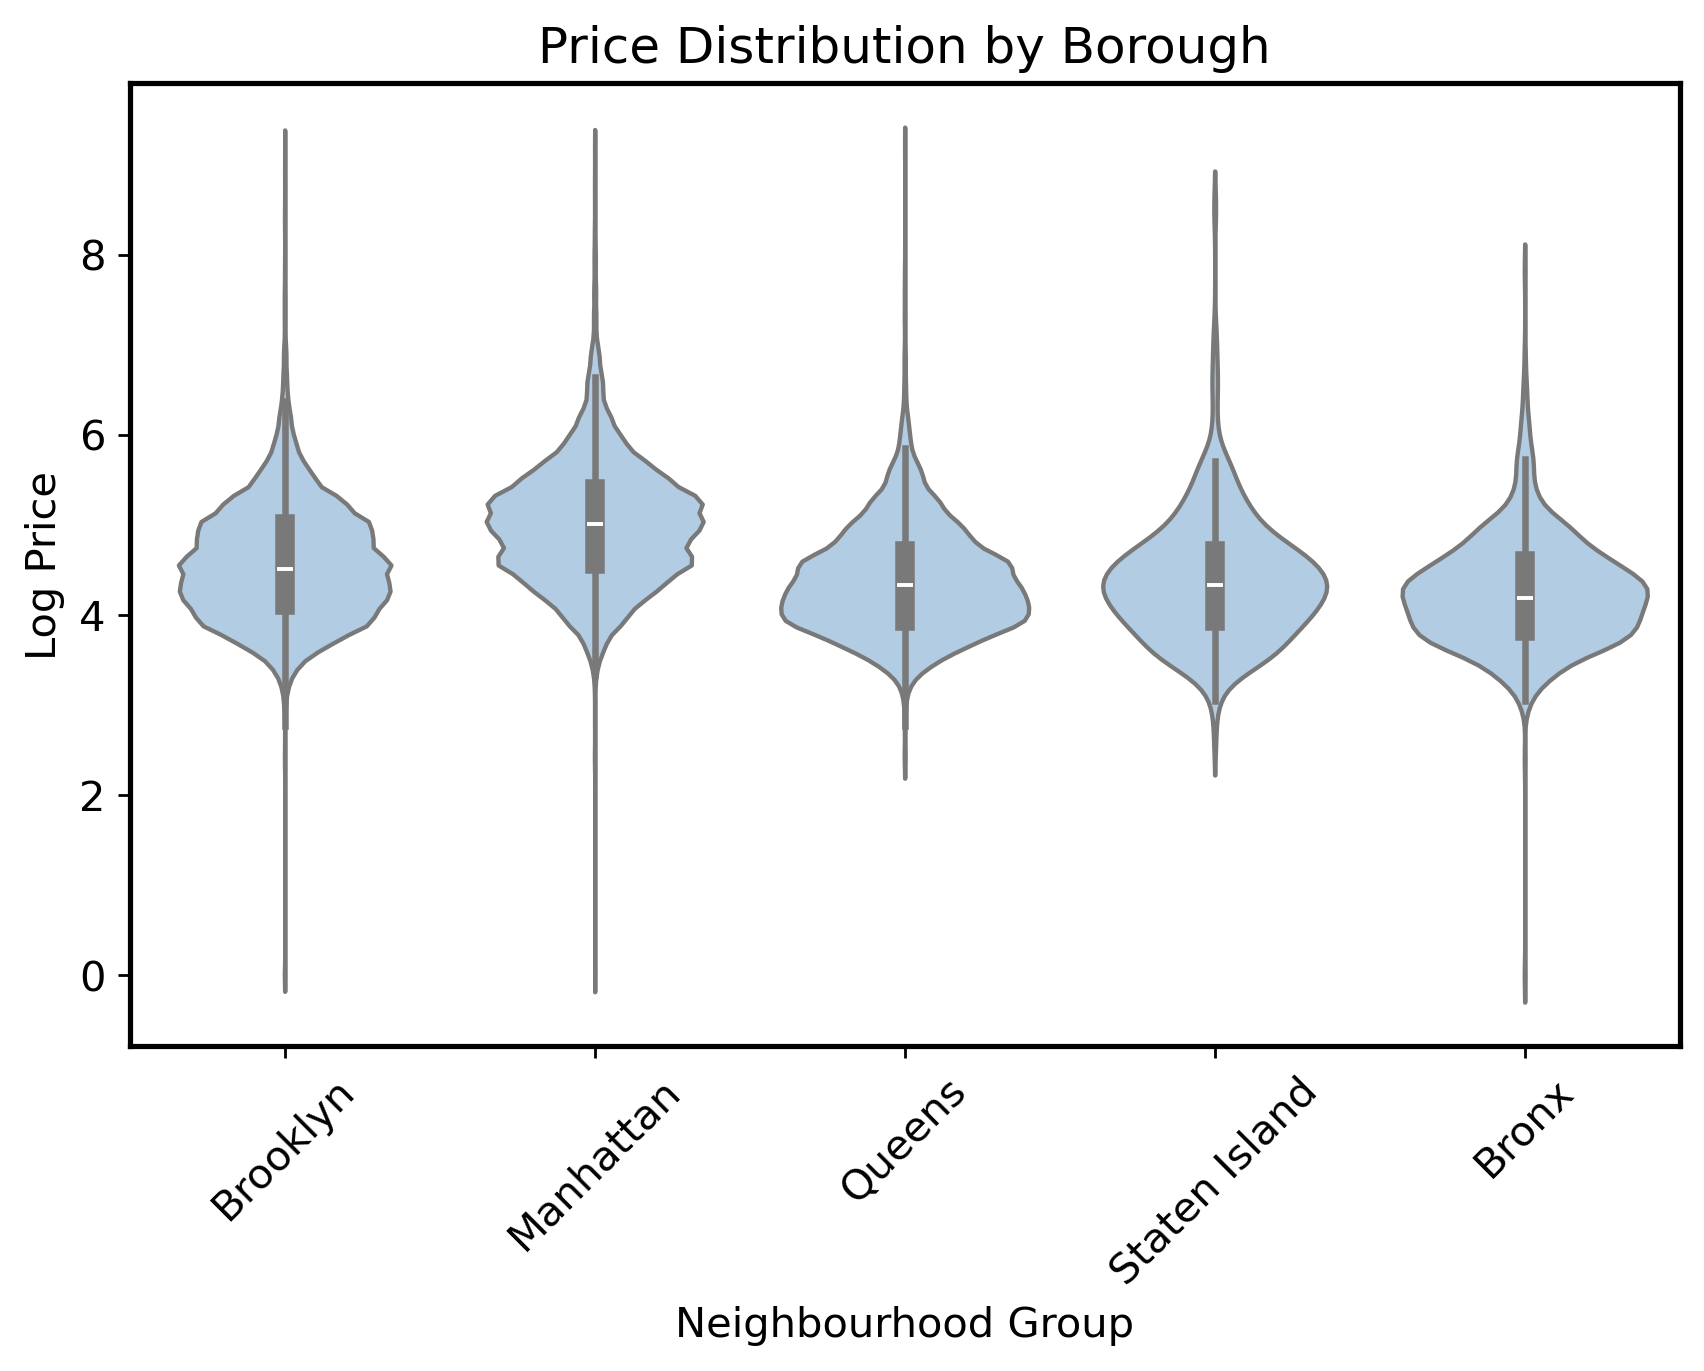

In [10]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="neighbourhood_group",
    y= np.log1p(df["price"]))
plt.title("Price Distribution by Borough")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Log Price")
plt.xticks(rotation=45)

plt.show()

The violin plot reveals clear differences in price distributions across boroughs. Manhattan has the highest median price and a distribution that is consistently shifted upward, indicating that listings are generally more expensive rather than simply driven by a few high-end outliers. Brooklyn follows as the second most expensive borough, while Queens, Staten Island, and the Bronx exhibit lower and more similar price distributions.

This suggests that geographic location sets the baseline for pricing across the platform.

### Room Type Analysis 

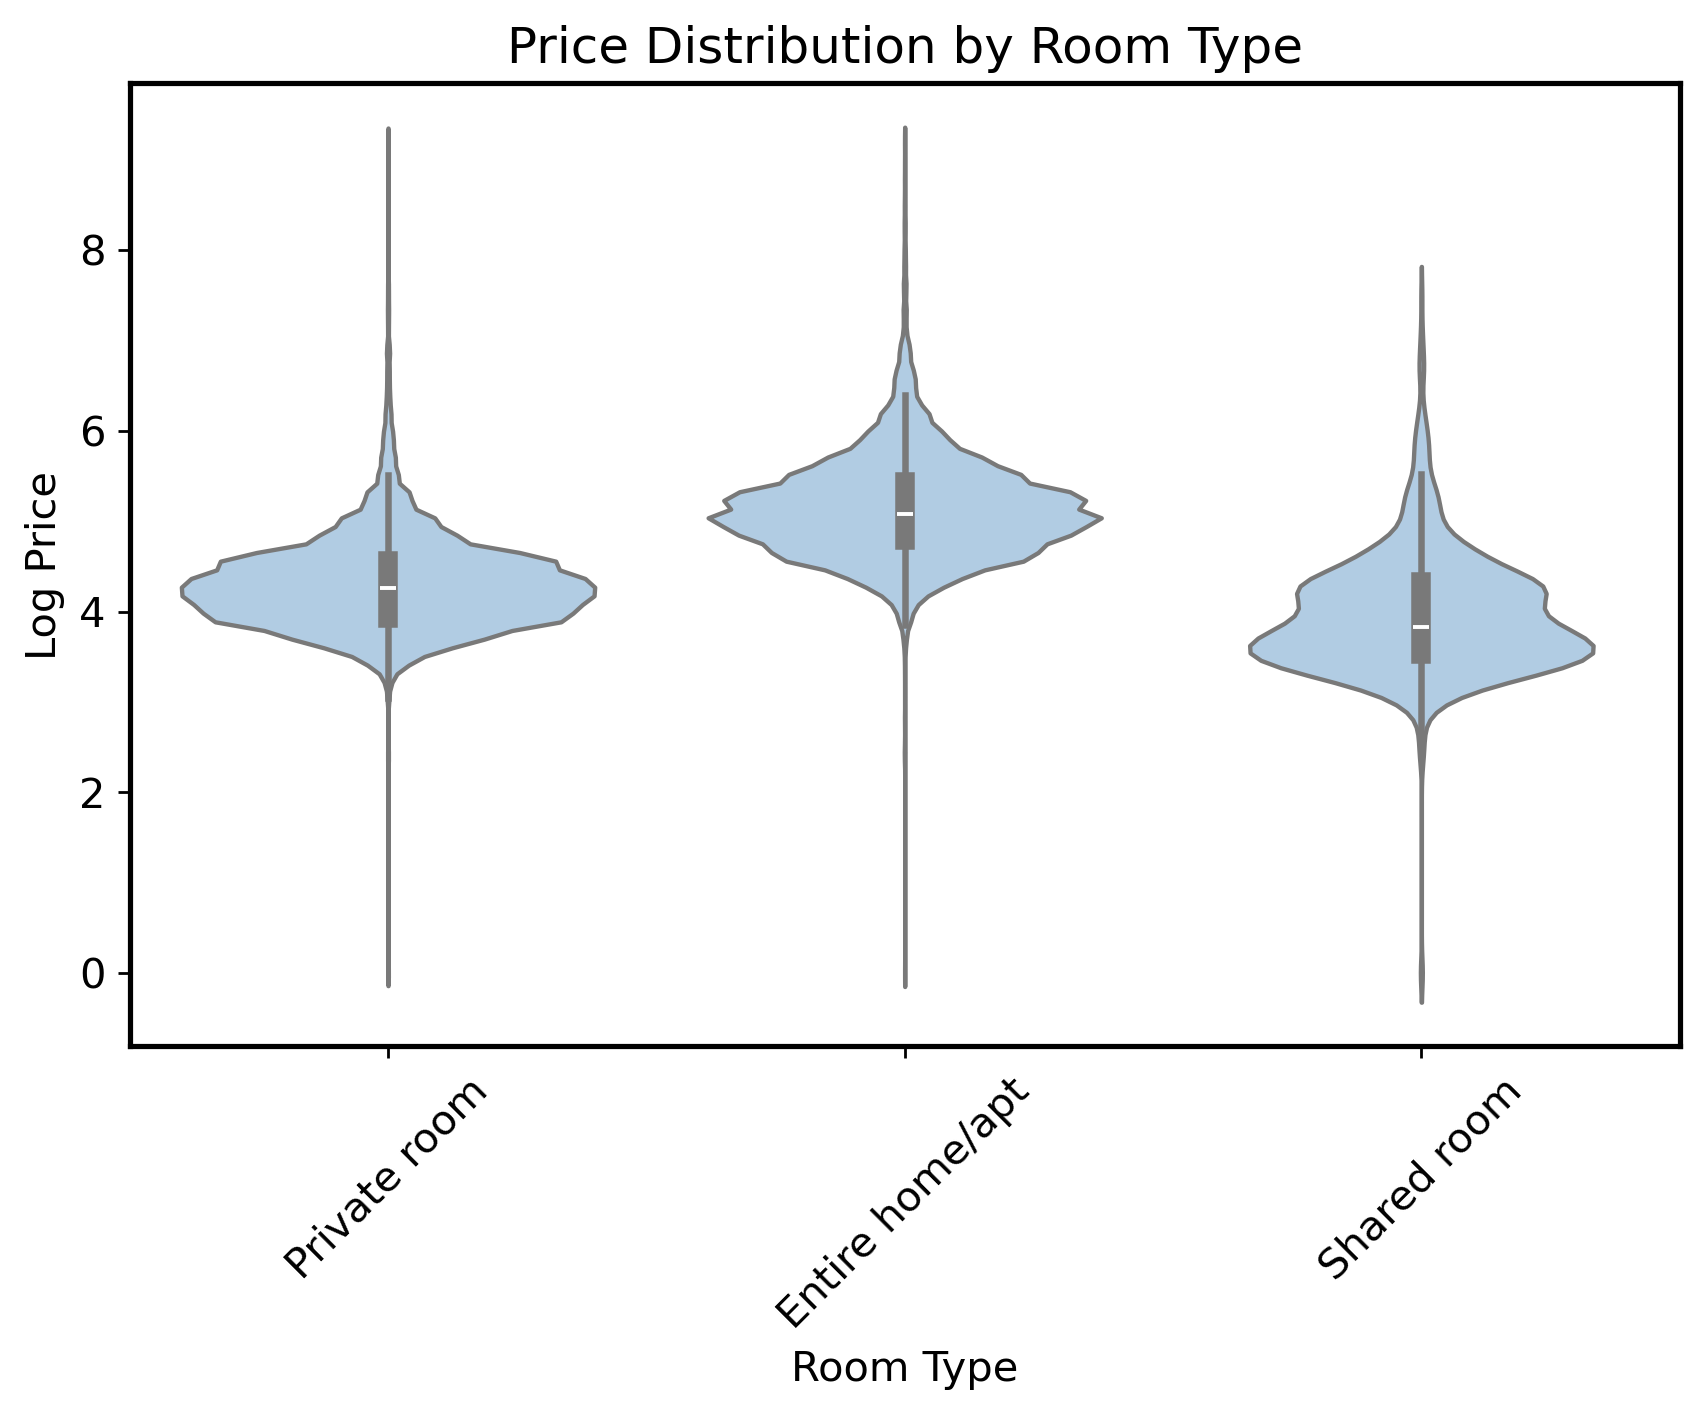

In [11]:
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="room_type",
    y= np.log1p(df["price"]))
plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Log Price")
plt.xticks(rotation=45)

plt.show()

The entire home/apt listings are the most expensive, followed by private rooms, with shared rooms being the least expensive. While there is some overlap between private rooms and entire homes, the distribution for entire homes is consistently shifted higher, indicating a strong pricing premium. 

This suggests that listing type is a major driver of price, likely reflecting differences in privacy and user experience.

### Reviews Analysis

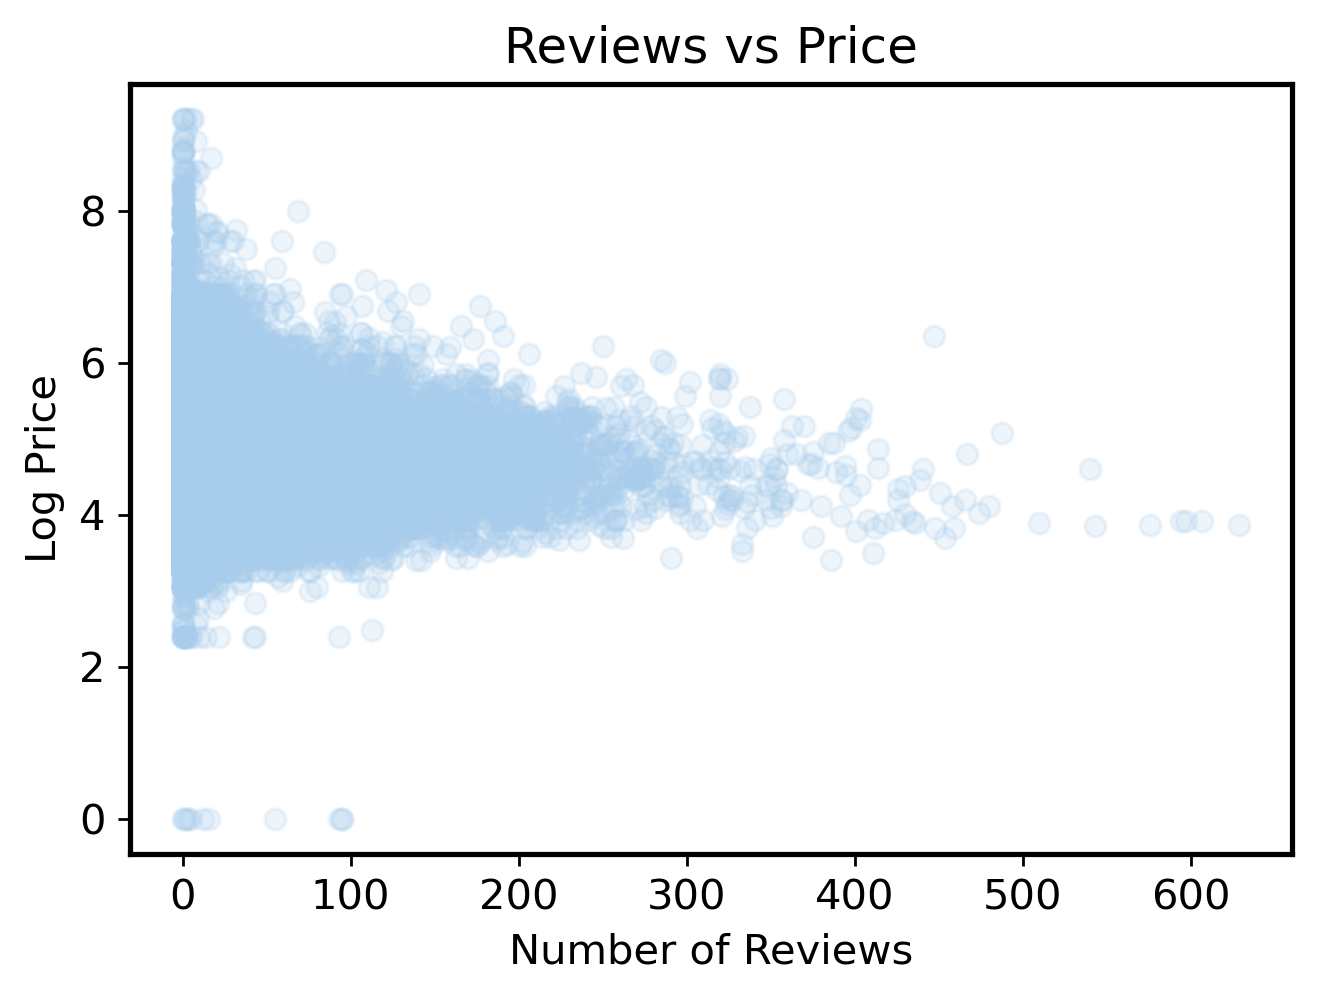

In [12]:
plt.figure(figsize=(6,4))

plt.scatter(df["number_of_reviews"], np.log1p(df["price"]), alpha=0.2)

plt.xlabel("Number of Reviews")
plt.ylabel("Log Price")
plt.title("Reviews vs Price")

plt.show()

This is sort of noisy, so lets group this by number of reviws into bins: low (0-20), medium (20-100), high (100+)

In [13]:
df["review_bin"] = pd.cut(
    df["number_of_reviews"],
    bins=[0, 20, 100, df["number_of_reviews"].max()],
    labels=["Low", "Medium", "High"]
)

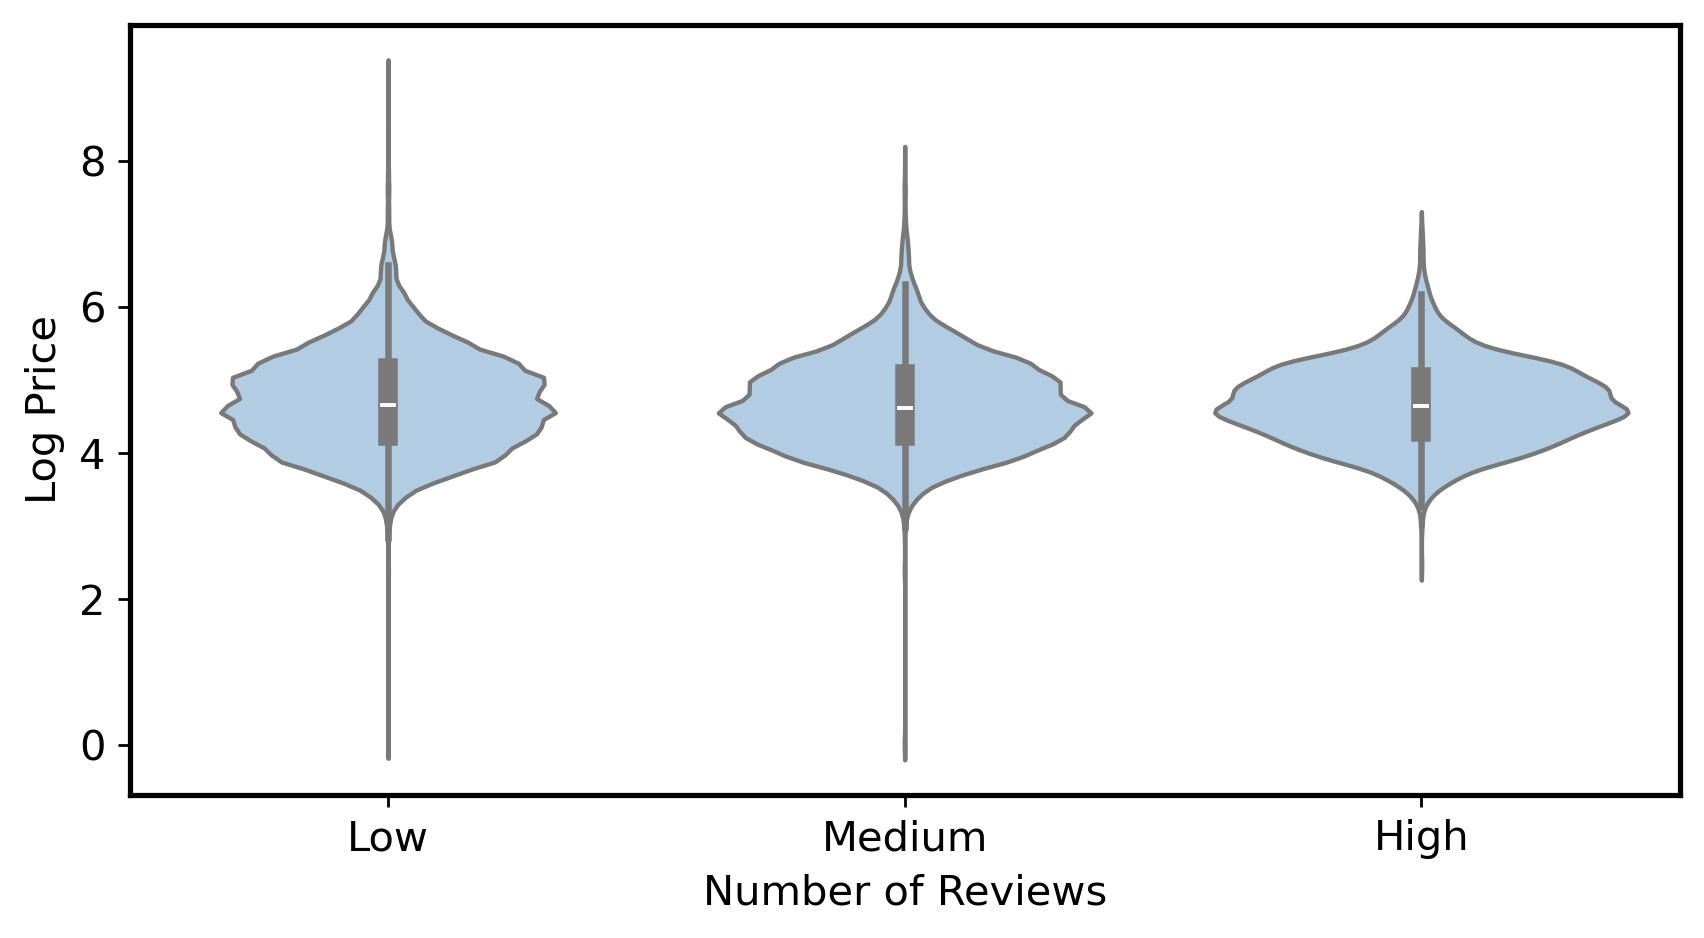

In [15]:
sns.violinplot(
    data=df,
    x="review_bin",
    y = np.log1p(df["price"])
)
plt.xlabel("Number of Reviews")
plt.ylabel("Log Price")
plt.show()

The relationship between number of reviews and price is weak and noisy, with no clear upward trend.

Further analysis shows that listings with a high number of reviews tend to have slightly lower price distributions. This suggests that more frequently booked (and likely more affordable) listings accumulate more reviews over time.

This indicates that reviews are better interpreted as a demand signal rather than a direct driver of pricing.

### Modeling Approach

To quantify the impact of different features on price, two models were used:

- Linear Regression: Provides interpretable coefficients and captures global trends
- Random Forest: Captures nonlinear relationships and feature interactions

The target variable is log(price), and features include location, room type, reviews, availability, and minimum nights.

In [16]:
# Lets prepare features 
features = [
    "neighbourhood_group",
    "room_type",
    "number_of_reviews",
    "availability_365",
    "minimum_nights"
]

In [17]:
# converts categories into numbers using one-hot encoding 
X = pd.get_dummies(df[features], drop_first=True) 
y = np.log1p(df["price"])

## Linear Model

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [20]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear RMSE:", rmse)
print("Linear R2:", r2)

Linear RMSE: 0.4958131444849289
Linear R2: 0.48036973778078385


In [21]:
# What features are important? 
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_
}).sort_values(by="coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient
4,neighbourhood_group_Manhattan,0.581916
3,neighbourhood_group_Brooklyn,0.262323
5,neighbourhood_group_Queens,0.124730
1,availability_365,0.000717
0,number_of_reviews,-0.000839
2,minimum_nights,-0.001594
6,neighbourhood_group_Staten Island,-0.007772
7,room_type_Private room,-0.773301
8,room_type_Shared room,-1.173519


## Linear Regression Results

The linear model achieves an R² of approximately 0.48, indicating that it explains nearly half of the variation in listing prices.

The model identifies location as the dominant driver of price. Listings in Manhattan are approximately 79% more expensive than the baseline borough, followed by Brooklyn (~30%) and Queens (~13%).

In contrast, variables such as number of reviews and availability have minimal impact on pricing. This suggests that structural features play a much larger role than demand-based signals.

## Random Forest Model

In [22]:
# lets now use a random forest 

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RF RMSE:", rmse_rf)
print("RF R2:", r2_rf)

RF RMSE: 0.505167265548104
RF R2: 0.4605778633144081


In [23]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

importances.head(10)

,feature,importance
7,room_type_Private room,0.373772
1,availability_365,0.218603
0,number_of_reviews,0.140426
2,minimum_nights,0.099047
8,room_type_Shared room,0.077902
4,neighbourhood_group_Manhattan,0.076593
3,neighbourhood_group_Brooklyn,0.008279
5,neighbourhood_group_Queens,0.004084
6,neighbourhood_group_Staten Island,0.001294


## Random Forest Results

The RF model identifies room type as the most important predictor of price, with availability and number of reviews also contributing meaningfully. While the linear model emphasized location as the dominant factor, the Random Forest suggests that room type may play an even stronger role when nonlinear relationships are considered.

# Model Comparision 
Comparing the two models provides a more complete understanding of pricing dynamics.

- The linear model emphasizes location as the primary driver of price
- The Random Forest identifies room type as the strongest feature and highlights the role of behavioral signals

Together, these results suggest that pricing is influenced by two layers:

1. Structural factors (location and room type), which establish baseline pricing
2. Behavioral factors (reviews, availability), which reflect demand and refine pricing within those constraints

This highlights the importance of combining interpretable and flexible models when analyzing real-world systems.

## Summary

Rental pricing is primarily driven by structural factors, particularly room type and location. Entire homes and listings in Manhattan command clear price premiums.

Behavioral features such as reviews and availability play a smaller role and appear to reflect demand rather than directly influence pricing.

Comparing linear and Random Forest models shows that pricing is shaped by both baseline structural differences and more complex listing-level dynamics. These findings suggest that rental platforms should prioritize location and listing type in pricing tools, while using behavioral signals to refine recommendations.

# Simulated A/B Test: Pricing Intervention and Demand 

To evaulate whether pricing adjustments could improve listing performance, I designed a simulated A/B test. High, priced, low-engagement listings were selected and randomly assinged to control and treatment groups. 

In this setup:
- **Control group:** listings retain their original price
- **Treatment group:** eligible listings receive a simulated 10% price reduction

I then compare the predicted probability of being a high-demand listing between the two groups.

In [24]:
df_ab = df.copy()

# Create binary demand label using the median number of reviews
median_reviews = df_ab["number_of_reviews"].median()
# If the number_of_reviews is greater than the med value, then it is a high demand 
df_ab["high_demand"] = (df_ab["number_of_reviews"] > median_reviews).astype(int)

print("Median number of reviews:", median_reviews)
df_ab[["number_of_reviews", "high_demand"]].head()

Median number of reviews: 5.0


,number_of_reviews,high_demand
0,9,1
1,45,1
2,0,0
3,270,1
4,9,1


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Features for demand prediction
features = [
    "price",
    "minimum_nights",
    "availability_365",
    "room_type",
    "neighbourhood_group"
]

X = df_ab[features].copy()
y = df_ab["high_demand"].copy()

# Remove obvious missing values if needed
X = X.replace([np.inf, -np.inf], np.nan)

categorical_features = ["room_type", "neighbourhood_group"]
numeric_features = ["price", "minimum_nights", "availability_365"] 

# Looks at numeric columns and fills in missing values using the median 
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Cleans missing cateogries, then converts them into numbers the model can understand 
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the right cleaning steps to the right columns
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ))
])

# Spits the data to training and testing 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['price', 'minimum_nights',
                                                   'availability_365']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['room_type',
                                                   'neighbourhood_group'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=8, n_estimators=200,
                                        random_state=42))])

In [26]:
from sklearn.metrics import classification_report, roc_auc_score

# Feed X test values into models  
y_pred = model.predict(X_test)
# The model’s estimated probability that the listing is high_demand (class = 1)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.70      0.70      0.70      4979
           1       0.69      0.68      0.69      4800

    accuracy                           0.69      9779
   macro avg       0.69      0.69      0.69      9779
weighted avg       0.69      0.69      0.69      9779

ROC-AUC: 0.7574330730735757


The model achieves an ROC-AUC of about 0.76, indicating a solid ability to distinguish between high- and low-demand listings. While not perfect, this level of performance is sufficient for estimating relative changes in demand under the simulated pricing experiment.

In [27]:
# Define eligible listings:
# expensive listings with below-median review counts

# Find the price where the top 25% of listings start 
price_threshold = df_ab["price"].quantile(0.75)
# Split listings into low vs high demand using the median
review_threshold = df_ab["number_of_reviews"].median()

# We are selecting expensive AND low-demand listings because we want to know, if a listing is expensive and not getting much 
# engagement would lowering the price help?
eligible = df_ab[
    (df_ab["price"] >= price_threshold) &
    (df_ab["number_of_reviews"] <= review_threshold)
].copy()

print("Eligible listings:", len(eligible))
eligible[["price", "number_of_reviews", "room_type", "neighbourhood_group"]].head()

Eligible listings: 7337


,price,number_of_reviews,room_type,neighbourhood_group
19,190,0,Entire home/apt,Manhattan
61,375,5,Entire home/apt,Manhattan
66,225,4,Entire home/apt,Brooklyn
140,250,3,Entire home/apt,Brooklyn
164,250,4,Entire home/apt,Manhattan


In [28]:
eligible["price"].describe()
eligible["number_of_reviews"].describe()

count    7337.000000
mean        1.277634
std         1.576107
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: number_of_reviews, dtype: float64

Eligible listings are randomly shuffled and split into control and treatment groups of equal size. The treatment group received a simulated 10% price reduction, while the control group retained the original price. This setup allows for a controlled comparison of predicted demand under a simple pricing intervention.

In [29]:
np.random.seed(42)

# shuffle the eligbile listings before assigning groups 
eligible = eligible.sample(frac=1, random_state=42).reset_index(drop=True)

# Assign control and treatment gorups; if in the first half, 'control' else 'treatement' 
eligible["group"] = np.where(
    np.arange(len(eligible)) < len(eligible) / 2,
    "control",
    "treatment"
)

eligible["price_original"] = eligible["price"]

# Apply a 10% price reduction to treatment group
eligible.loc[eligible["group"] == "treatment", "price"] = (
    eligible.loc[eligible["group"] == "treatment", "price"] * 0.90)

eligible[["price_original", "price", "group"]].head()

/var/folders/rk/888fv3n533n_d0tlr213d9h40000gn/T/ipykernel_81199/4143198895.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[261.  535.5 810.  ... 283.5 360.  180. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  eligible.loc[eligible["group"] == "treatment", "price"] = (


,price_original,price,group
0,175,175.0,control
1,200,200.0,control
2,200,200.0,control
3,375,375.0,control
4,191,191.0,control


In [30]:
# For each listing, estimate the probability that it is high demand given its features (including the updated price) 

# Predict high-demand probability after treatment assignment
eligible["predicted_high_demand_prob"] = model.predict_proba(
    eligible[features]
)[:, 1]

# Compared average predicted demand (control) vs. treatment 
summary = eligible.groupby("group")["predicted_high_demand_prob"].agg(["mean", "std", "count"])
summary

,mean,std,count
group,,,
control,0.368004,0.180903,3669
treatment,0.396325,0.185016,3668


In [31]:
from scipy.stats import ttest_ind

control_probs = eligible.loc[
    eligible["group"] == "control", "predicted_high_demand_prob"
]
treatment_probs = eligible.loc[
    eligible["group"] == "treatment", "predicted_high_demand_prob"
]

t_stat, p_value = ttest_ind(treatment_probs, control_probs, equal_var=False)

print("Control mean predicted demand:", control_probs.mean())
print("Treatment mean predicted demand:", treatment_probs.mean())
print("Absolute uplift:", treatment_probs.mean() - control_probs.mean())
print("Relative uplift (%):", 100 * (treatment_probs.mean() - control_probs.mean()) / control_probs.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)

Control mean predicted demand: 0.36800367838655573
Treatment mean predicted demand: 0.3963246841633655
Absolute uplift: 0.028321005776809793
Relative uplift (%): 7.695848558084533
t-statistic: 6.629100277411027
p-value: 3.6170363296090114e-11


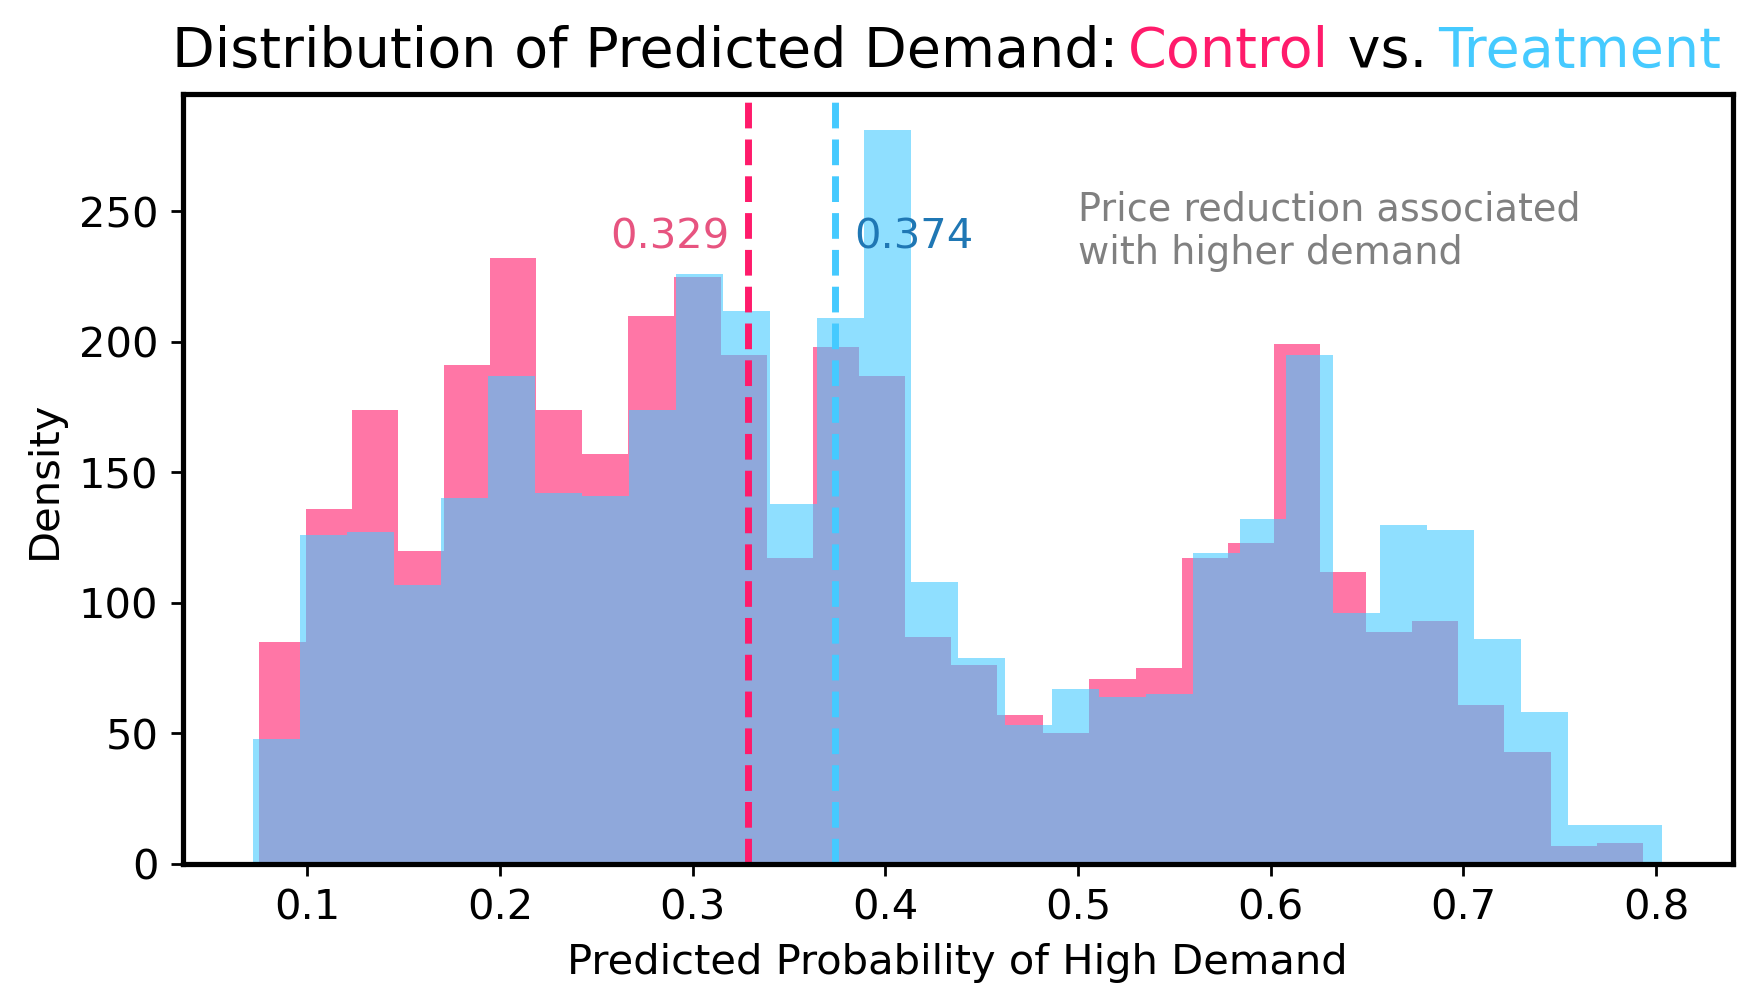

In [32]:
binsize = 30 
alpha = 0.6
control_color = '#ff1b6b'
treatment_color = '#45caff'

# Compute medians
control_median = np.median(control_probs)
treatment_median = np.median(treatment_probs)


plt.hist(control_probs, bins = binsize,  alpha = alpha, label="Control", color=control_color)
plt.hist(treatment_probs,bins = binsize, alpha = alpha, label="Treatment", color=treatment_color)

# Add vertical lines for medians
plt.axvline(control_median, linestyle="--", linewidth=2,  color=control_color)
plt.axvline(treatment_median, linestyle="--", linewidth=2,  color=treatment_color)

# Add axis 
plt.xlabel("Predicted Probability of High Demand")
plt.ylabel("Density")

ax = plt.gca()
ax.set_title("")  # remove default title

# Left part
ax.text(0.615, 1.02, "Distribution of Predicted Demand: ",
        transform=ax.transAxes,
        ha='right', va='bottom',
        fontsize=16,  color="black")

# "Control" in pink
ax.text(0.61, 1.02, "Control",
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=16, color=control_color)

# " vs. " in black
ax.text(0.74, 1.02, " vs. ",
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=16, color="black")

# "Treatment" in blue
ax.text(0.81, 1.02, "Treatment",
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=16, color=treatment_color)


# Place text slightly above the bars
plt.text(control_median-0.010, plt.ylim()[1]*0.8,
         f"{control_median:.3f}",
         color="#e75480",
         ha="right")

plt.text(treatment_median+0.010, plt.ylim()[1]*0.8,
         f"{treatment_median:.3f}",
         color="#1f77b4",
         ha="left")

plt.text(
    0.5, 230,
    "Price reduction associated\nwith higher demand",
    color="gray",
    ha="left",
    fontsize=11
)

#plt.legend()
plt.show()

The simulated pricing intervention suggests that reducing prices for underperforming listings may increase expected demand, with an estimated uplift of 7–8% based on model predictions.

## Results

In summary, listings in the top quartile of price and below-median in engagment were selected as candidates for a pricing intervention. These listings were randomly split into control and treatment groups, where the treatment group received a simulated 10% price reduction. Predicted demand was then compared between groups to evaluate the potential impact of the intervention.

The treatment group, which received a simulated 10% price reduction, showed a higher average predicted probability of high demand (0.396) compared to the control group (0.368). This corresponds to an absolute increase of a relative uplift of ~7.7%. This suggests that targeted price reductions for underperforming listings may improve expected demand. A two-sample t-test indicates that this difference is statistically significant (p < 0.001), suggesting that the observed uplift is unlikely to be due to random variation.

While this analysis is based on model predictions and a proxy for demand rather than actual booking outcomes, the results provide directional evidence that targeted price reductions for high-priced, low-engagement listings may improve expected performance. A natural next step would be to validate these findings using real user-level booking in a true randomized experiment.

### Recommendation

These results suggest that pricing is a meaningful lever for improving listing performance. Platforms could consider targeted price recommendations for high-priced, low-engagement listings rather than applying broad discounts across all properties.